In [194]:
import os
import import_ipynb
import matplotlib.pyplot as plt
from matplotlib import colors

from scipy.optimize import root_scalar

import prodimopy.read as pread
import prodimopy.plot as pplot

from scipy import integrate
from scipy.special import gammaincc, gamma
from scipy.interpolate import interp1d
import scipy.special
import numpy as np
from matplotlib.colors import LogNorm


In [195]:
ecgs=4.8*10**-10
kBeV= 8.61*10**(-5)  #La constante de Boltzmann en eV*K-1
msol=2.0*10.0**33       #La masse du soleil en grammes
ergtoeV=6.242e+11
autocm=1.496e+13
mp=1.67*10.0**-24       # La masse du proton en g
me=9.11*10.0**-28       # La masse de l'electron en g
c_light=2.99*1E10         #La vitesse de la lumière en cm/s
kB=1.380649*10.0**-16    #La constante de Boltzmann en ergs*K-1
mpeVsurc2=938.3*10.0**6 #La masse du proton en eV
meeVsurc2=511.0*10.0**3 #La masse de l'électron en eV

In [196]:
#MstarDMTau=0.53*msol, MstarTTauri=0.7*msol, MstarMWC480=1.97*msol,MstarRECX15=0.28*msol
#Mstar=1.97*msol
DiscModelName="TTauriFiducialEP" #"ClassINOEP"#"DMTau_ModelOutput"#"RECX15_ModelOutput"

Kappa=1


In [197]:
def IncompGamma(a, x):
    # Regularized upper incomplete gamma function
    return gammaincc(a, x) * gamma(a)
def BetaProton(Ec):
    E=Ec/mpeVsurc2
    return np.sqrt(((1+E)**2-1)/(1+E)**2)
    

def BetaElectron(Ec): 
    E=Ec/meeVsurc2
    return np.sqrt(((1+E)**2-1)/(1+E)**2)


In [198]:
def LElectronAnalytic(E):
    enr=1e3
    etrel=3.2*1e5
    erel=3*1e8
    LElectronH21e3=1.07e-15
    if E<etrel:
        return LElectronH21e3*(E/enr)**-0.8
    if E>=etrel and E<erel:
        return LElectronH21e3*(etrel/enr)**-0.8*(E/etrel)**0.12
    if E>=erel:
        return LElectronH21e3*(etrel/enr)**-0.8*(erel/etrel)**0.12*(E/erel)**0.9
    
def RangeFunction(E,LossFunction):
    """
    Calculate the R(E) value for a given energy for protons.

    Parameters:
    E (float): The energy value.

    Returns:
    float: The R(E) value for protons.

    """
    E_Integration_array=np.logspace(-1, np.log10(E), 500)
    LossFunctionArray=np.array([LossFunction(e) for e in E_Integration_array])
    Integrande = 1 / LossFunctionArray
    Range = np.trapezoid(Integrande, x=E_Integration_array)
    
    return np.array(Range)




In [199]:
DiscModel = pread.read_prodimo(directory='PMODELS/'+DiscModelName, name=None, readlineEstimates=True, readObs=True,
                                  readImages=True, filename="ProDiMo.out", filenameLineEstimates="FlineEstimates.out",
                                  filenameLineFlux="line_flux.out", td_fileIdx=None)

READ: StarSpectrum.out ...
READ: RTinterpolation.out ...
READ: Species.out ...


READ: FlineEstimates.out: 100%|██████████| 80387/80387 [00:02<00:00, 38693.73it/s]


READ: Elements.out ...
READ: dust_opac.out ...
READ: dust_sigmaa.out ...
READ: SED.out ...
READ: SEDana.out ...
READ: image.out ...
READ: Parameter.out ...
INFO: Reading time:  2.76 s
 


In [200]:
# DiscModel and viscosity model
'''
DensityH2Array = np.flip(DiscModel.getAbun('H2') * DiscModel.nHtot, axis=1)
DensityHArray = np.flip(DiscModel.getAbun('H') * DiscModel.nHtot, axis=1)
DensityHeArray = np.flip(DiscModel.getAbun('He') * DiscModel.nHtot, axis=1)

DensityHplusArray = np.flip(DiscModel.getAbun('H+') * DiscModel.nHtot, axis=1)
DensityCplusArray = np.flip(DiscModel.getAbun('C+') * DiscModel.nHtot, axis=1)
DensityCArray = np.flip(DiscModel.getAbun('C') * DiscModel.nHtot, axis=1)
DensityCOArray = np.flip(DiscModel.getAbun('CO') * DiscModel.nHtot, axis=1)
HeatingRateTotArray = np.flip(DiscModel.heat, axis=1)
CoolingRateTotArray = np.flip(DiscModel.cool, axis=1)
'''
Mstar=DiscModel.mstar*msol
TemperatureGas = np.flip(DiscModel.tg, axis=1)
grilleZAUliste = np.flip(DiscModel.z*autocm, axis=1)
grilleXAUliste = np.flip(DiscModel.x*autocm, axis=1)
densiteHmoyliste = np.flip(DiscModel.nHtot,axis=1)
densiteEliste = np.flip(DiscModel.getAbun('e-') * DiscModel.nHtot, axis=1)

#VerticalColumnDensity=SFRM.ColumnDensityArray()




/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/2574139311.py:14: DeprecationWarning: Use model.star.mass instead.
  Mstar=DiscModel.mstar*msol


In [201]:
def GasPressureMidPlane(TemperatureGas,densiteHmoyliste):
    Pmid=np.ones(np.shape(TemperatureGas))
    Ptemp=[]
    for i in range (len(TemperatureGas)):
        Ptemp.append(TemperatureGas[i][-1]*densiteHmoyliste[i][-1])
    for j in range (len(TemperatureGas[-1])):
        for i in range (len(TemperatureGas)):
            Pmid[i,j]=Ptemp[i]
    Pmid=np.array(Pmid)
    return Pmid


def Am(densiteEliste,densiteHmoyliste):
    return grilleXAUliste**(3/2)*densiteEliste/densiteHmoyliste/1E-8*densiteHmoyliste/1E10  # Eq 19 B24

def Rm(TemperatureGas,densiteEliste,densiteHmoyliste):
    return grilleXAUliste**(3/2)*densiteEliste/densiteHmoyliste/1E-13*(TemperatureGas/100)**0.5 # Eq.

def LO(TemperatureGas,densiteHmoyliste,densiteEliste):
    betamag=BetaMagnetic(TemperatureGas,densiteHmoyliste)
    return grilleXAUliste**(3/2)*densiteEliste/densiteHmoyliste/1E-9*(TemperatureGas/100)**0.5*(10**4/betamag) # Eq 19 ''

def MagneticIntensity(TemperatureGas,densiteHmoyliste):
    betamag=BetaMagnetic(TemperatureGas,densiteHmoyliste)
    return np.sqrt(8*np.pi*densiteHmoyliste*kB*TemperatureGas/betamag)

def IonSoudRadius(TemperatureGas,densiteHmoyliste):
    betamag=BetaMagnetic(TemperatureGas,densiteHmoyliste)
    return np.sqrt(mp*c_light**2/(4*np.pi))/ecgs* betamag**0.5 * densiteHmoyliste**(-0.5)


def alphavisc(TemperatureGas,densiteHmoyliste,densiteEliste,grilleXAUliste): #Thi et al. 2019
    betamag=BetaMagnetic(TemperatureGas,densiteHmoyliste)
    LOl=LO(TemperatureGas,densiteHmoyliste,densiteEliste)
    Aml=Am(densiteEliste,densiteHmoyliste)
    delta=0.5
    minval = np.where(LOl < 1, LOl, 1)
    alphai=np.where(betamag>1,(2/betamag)**0.5,10**(-1.9+0.57*(np.arctan((4.2-np.log10(betamag))/0.5))**(-1)))
    #alphai=np.where(betamag<1,0.1,(2/betamag)**0.5)
    MRIactiv=np.where(betamag**0.5*LOl<1,0,1)
    return MRIactiv*alphai*minval*((50/Aml**1.2)**2+(8/Aml**0.3+1)**2)**(-delta)
def MachNumber(TemperatureGas,densiteHmoyliste,densiteEliste,grilleXAUliste):
    alpha=alphavisc(TemperatureGas,densiteHmoyliste,densiteEliste,grilleXAUliste)
    
    betamag=BetaMagnetic(TemperatureGas,densiteHmoyliste)
    
    return (2*alpha*betamag)**0.5
def OmegaKeplerian(Mstar,grilleXAUliste):
    return 2*1E-7*(Mstar/msol)**(1/2)*grilleXAUliste**-(3/2) 
def Soundspeed(TemperatureGas):
    return (kB/(1.5*1.6*1E-24)*TemperatureGas)**0.5  # in cm/s
def Alfvenspeed(TemperatureGas,densiteHmoyliste):
    betamag=BetaMagnetic(TemperatureGas,densiteHmoyliste)
    return (2/betamag)**0.5*Soundspeed(TemperatureGas)  # in cm/s
def ScaleHeight(TemperatureGas,grilleXAUliste,Mstar):
    return Soundspeed(TemperatureGas)/OmegaKeplerian(Mstar,grilleXAUliste)  # in cm

def BetaMagnetic(TemperatureGas,densiteHmoyliste): #Thi et al. 2019
    Pmid=GasPressureMidPlane(TemperatureGas,densiteHmoyliste)
    discontinuity=False
    Factor=1
    pmid=[]
    rlist=[]
    for i in range(len(Pmid)):
        pmid.append(Pmid[i,0])
        rlist.append(grilleXAUliste[i,0])
    
    for j in range(0,len(pmid)-1):
        diff=pmid[j+1]/pmid[j]
        if diff>500:
            discontinuity=True
            if grilleXAUliste[j,0]>2:
                Factor=diff
                Rdiscontinuity=grilleXAUliste[j+1,0]
                Jdiscontinuity=j+1
                

    betamid=[] 
    if discontinuity==True:           
        for j in range (0,len(rlist)):
            if j<Jdiscontinuity:
                betamid.append([10**4/Factor]*len(TemperatureGas[0]))
            else:
                betamid.append([10**4]*len(TemperatureGas[0]))
    else:
        betamid.append([10**4]*len(TemperatureGas[0]))
    betamid=np.array(betamid)
    betamag=betamid*densiteHmoyliste*TemperatureGas/Pmid  # Plasma beta at mid-plane = 10**4 Thi et al. 2019
    return betamag

In [202]:

from scipy.integrate import quad

def IonizationRateAnalytic(j0, e0, a, b, L0, N, R0):
    epsilon = 37.0  # eV

    gamma1 = (a + b - 1) / (1 + b)

    def integrand(x):
        return (x**(1 + b) + 1)**(-(a + b) / (1 + b))

    If, _ = quad(integrand, 0, np.inf)

    N0f = e0 / ((1 + b) * L0)

    zeta = (1 + b) / (a + 2 * b) * If * j0 * e0 * L0 / epsilon * (N / N0f) ** (-gamma1)

    return zeta

In [203]:
def IonisationRatesVerticalAnalytic(Zetaliste, ZIndexAccelerationRegion, ir):
    local = []
    widths = []

    for j, iz in enumerate(ZIndexAccelerationRegion):
        dz = grilleZAUliste[ir][iz+1] - grilleZAUliste[ir][iz]
        widths.append(dz)
        local.append(np.asarray(Zetaliste[j]) * dz)

    widths = np.asarray(widths)
    total_width = widths.sum()

    local = np.asarray(local)                      # shape: (nZ, nN)
    total_ionisation_rate_EP = local.sum(axis=0) / total_width  # shape: (nN,)
    
    return total_ionisation_rate_EP

In [204]:
MachNumberl=MachNumber(TemperatureGas,densiteHmoyliste,densiteEliste,grilleXAUliste)

AlfvenicMachNumberl=np.where(MachNumberl>0.001,MachNumberl,0)
alphaviscl=alphavisc(TemperatureGas,densiteHmoyliste,densiteEliste,grilleXAUliste)
ScaleHeightl=ScaleHeight(TemperatureGas,grilleXAUliste,Mstar)
MagneticIntensityl=MagneticIntensity(TemperatureGas,densiteHmoyliste)
BetaMagneticl=BetaMagnetic(TemperatureGas,densiteHmoyliste)
#%%
eth=3/2*kBeV*TemperatureGas #Thermal energy in eV

#Turbulence model
LsurH=np.sqrt(alphaviscl)
#LsurH=np.full_like(alphaviscl, 1)

#Magnetic Reconnection parameters
alphaacc=np.full_like(densiteHmoyliste, 2/3) #tacc^-1 in unit ta
tauinj=AlfvenicMachNumberl**-2 #tinj in unit ta
DeltaRec=AlfvenicMachNumberl**2*LsurH *ScaleHeightl #Reconnection size in cm
tauesc=np.full_like(densiteHmoyliste, 1) #tesc in unit ta
betaacc=1/(alphaacc*tauesc)

Tacc=AlfvenicMachNumberl**-1 #Acceleration process duration in unit ta


emaxturbtime=np.exp(alphaacc*Tacc)
emaxHillas=ecgs*DeltaRec*MagneticIntensityl * ergtoeV/eth # larmor radius greater than outflow size Delta=Ma^2 L Xu
emax = np.minimum(emaxturbtime, emaxHillas)




Uthth=densiteHmoyliste * eth #Thermal energy density in eV/cm3
#UntsurTh=3/4 * LsurH**2/alphaacc *  AlfvenicMachCut**2
UntsurTh=3/4 * 1/(tauinj*alphaacc) *  LsurH**2 
#emax=np.where(AlfvenicMachCut>1, einj+1, emax) #Maximum energy in unit Eth
#emax=np.where(alphaviscl<0.01, einj+1, emax) #Maximum energy in unit Eth
#print('Maximum energy in eV:', np.nanmax(emax/1e9), 'GeV')


/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/3629658116.py:38: RuntimeWarning: overflow encountered in power
  alphai=np.where(betamag>1,(2/betamag)**0.5,10**(-1.9+0.57*(np.arctan((4.2-np.log10(betamag))/0.5))**(-1)))
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/2733085760.py:17: RuntimeWarning: divide by zero encountered in power
  tauinj=AlfvenicMachNumberl**-2 #tinj in unit ta
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/2733085760.py:22: RuntimeWarning: divide by zero encountered in reciprocal
  Tacc=AlfvenicMachNumberl**-1 #Acceleration process duration in unit ta


In [205]:
def MaxwellDistribution(epsilon0,nth):
    
    F=2* nth/(np.sqrt(np.pi)*epsilon0**(1/2))*np.exp(-epsilon0)
    return F

def InjectionEnergy(A, B, beta,emax):
    def equation(x):
        lhs = x**(3/2 + beta) * np.exp(-x)
        rhs = 1/(A*B) * (IncompGamma(3/2 + beta, x/ emax) - IncompGamma(3/2 + beta, x))
        return lhs - rhs

    # Initial guess: x must be positive, try a reasonable range
    sol = root_scalar(equation, bracket=[1e-6, 100], method='brentq')
    if sol.converged:
        return sol.root
    else:
        raise RuntimeError("Root finding did not converge.")

def InjectionDensity(nth,alphaacc,tauinj,emax,betaacc,LsurH,AlfvenicMachNumberl):
    if emax > 20:
            #print(emax[i][j])
            einj = InjectionEnergy(alphaacc, tauinj, betaacc, emax)

            if emax > einj:
                if einj > 2 :
                    #ninj[i][j]=InjectionDensity(LsurH[i][j],emax[i][j],einj[i][j],alphaacc[i][j])* densiteHmoyliste[i][j]
                    

                    ninjth=3*np.sqrt(np.pi)/(8*scipy.special.factorial(1/2+betaacc))*(LsurH)**2 * AlfvenicMachNumberl**-1*(betaacc-1)*(einj)**(betaacc-1)*nth #Injection density in cm^-3

    return ninjth
def TurbulentDistribution(epsilon0,ninj,alpha,tinj,tesc,emax):
    
    beta=1/(tesc*alpha)
    gamma=alpha*tinj
    Gammaad=5/3
    #print(2*ninj/(np.sqrt(np.pi)*gamma)*(GF.IncompGamma(3/2+beta,epsilon0/emax)-GF.IncompGamma(3/2+beta,epsilon0)))
    F=Gammaad*2*ninj/(np.sqrt(np.pi)*gamma)*epsilon0**-(1+beta)*(IncompGamma(3/2+beta,epsilon0/emax)-IncompGamma(3/2+beta,epsilon0))
    #F=2*ninj/(np.sqrt(np.pi)*gamma)*epsilon0**-(1+beta)
    #print((IncopGamma(3/2+beta,epsilon0*np.exp(-alpha*t))))
    return F

def TurbulentElectronFlux(E,T,ninj,alphaacc,tinj,tesc,emax):
    eth=3/2 * kBeV * T
    epsilon0=E/eth
    F=eth*TurbulentDistribution(epsilon0,ninj,alphaacc,tinj,tesc,emax)*BetaElectron(E)*c_light/(4*np.pi)  #part cm^-2 s^-1 eV^-1 sr-1
    return F

def TurbulentProtonFlux(E,T,ninj,alphaacc,tinj,tesc,emax):
    eth=3/2 * kBeV * T
    epsilon0=E/eth
    F=eth*TurbulentDistribution(epsilon0,ninj,alphaacc,tinj,tesc,emax)*BetaProton(E)*c_light/(4*np.pi)  #part cm^-2 s^-1 eV^-1 sr-1
    return F


In [206]:
def LElectronAnalytic(E):
    enr=1e3
    etrel=3.885*1e5
    erel=2.218*1e8
    bnr=0.754
    btr=-0.11
    br=-0.801

    LElectronH21e3=1.07e-15
    if E<etrel:
        return LElectronH21e3*(E/enr)**-bnr
    if E>=etrel and E<erel:
        return LElectronH21e3*(etrel/enr)**-bnr*(E/etrel)**-btr
    if E>=erel:
        return LElectronH21e3*(etrel/enr)**-bnr*(erel/etrel)**-btr*(E/erel)**-br

def LProtonAnalytic(E):
    enr=1e3
    etrel=7.939e4
    erel=3.458e8
    bnr=-0.384
    btr=0.771
    br=-0.938

    LProtonH21e3=2.8145013525728198e-15
    if E<etrel:
        return LProtonH21e3*(E/enr)**-bnr
    if E>=etrel and E<erel:
        return LProtonH21e3*(etrel/enr)**-bnr*(E/etrel)**-btr
    if E>=erel:
        return LProtonH21e3*(etrel/enr)**-bnr*(erel/etrel)**-btr*(E/erel)**-br




In [222]:


emaxlimit = 1e3

radial_indices = range(len(grilleXAUliste))
Ncol = DiscModel.NHver

ZetaEPrimMap = []

# ---------------------------------------------------------------------
# ELECTRONS: only trans-relativistic + relativistic, as the ionization rate from sub-relativistic electrons is negligible and the CSDA overestimates it in this regime. 
# ---------------------------------------------------------------------
E0E_TREL = 3.9e5
E0E_REL  = 2.2e8

FIT_E_TREL = (2.25, -0.11)
FIT_E_REL  = (2.5, -0.8)

LossE = LElectronAnalytic

Acceleration_Region = []
rindexnonEP = []

for r_idx in radial_indices:

    zeta_layers = []
    accel_z_indices = []

    nz = len(grilleZAUliste[0])
    accel_region = []

    for z_idx in range(nz):

        nH = densiteHmoyliste[r_idx][z_idx]
        emax_loc = emax[r_idx][z_idx]

        if not (emax_loc > emaxlimit and nH > 1e3):
            accel_region.append(0)
            continue

        accel_region.append(1)
        accel_z_indices.append(z_idx)

        Tgas = TemperatureGas[r_idx][z_idx]

        alpha = alphaacc[r_idx][z_idx]
        tauinj_loc = tauinj[r_idx][z_idx]
        tauesc_loc = tauesc[r_idx][z_idx]
        beta_loc = betaacc[r_idx][z_idx]
        L_over_H = LsurH[r_idx][z_idx]
        MA = AlfvenicMachNumberl[r_idx][z_idx]

        ninj = InjectionDensity(
            nH, alpha, tauinj_loc, emax_loc, beta_loc, L_over_H, MA
        )

        def make_logzeta_interp(e0, a, b):
            j0 = TurbulentElectronFlux(
                np.array(e0), Tgas, ninj, alpha, tauinj_loc, tauesc_loc, emax_loc
            )
            R0 = RangeFunction(np.array(e0), LossE)
            L0 = LossE(e0)
            logzeta = np.log10(
                IonizationRateAnalytic(j0, e0, a, b, L0, Ncol[r_idx], R0)
            )
            return interp1d(np.log10(Ncol[r_idx]), logzeta, fill_value="extrapolate"), R0

        interp_trel, R0E_trel = make_logzeta_interp(E0E_TREL, *FIT_E_TREL)
        interp_rel,  R0E_rel  = make_logzeta_interp(E0E_REL,  *FIT_E_REL)

        RmaxE = RangeFunction(np.array(emax_loc), LossE)

        # Continuity factor between trans-rel and rel
        A_rel = (
            10**interp_trel(np.log10(R0E_rel))
            / 10**interp_rel(np.log10(R0E_rel))
        )

        def zeta_electron(N):
            logN = np.log10(N)

            if N < R0E_rel:
                return 10**interp_trel(logN)

            return A_rel * 10**interp_rel(logN)

        zetaE = np.array([zeta_electron(N) for N in Ncol[r_idx]])

        cutoff_scale = min(RmaxE, R0E_rel)
        a_rel = FIT_E_REL[0]

        attenuation = (
            np.exp(-(Ncol[r_idx] / cutoff_scale)) ** (a_rel + 1)
            * np.exp(-(Ncol[r_idx] / RmaxE)) ** (a_rel + 1)
        ) ** 2

        zeta_total = zetaE * attenuation

        # factor 2 if IR per H2 molecule
        zeta_layers.append( zeta_total)

        summed_zeta = IonisationRatesVerticalAnalytic(
            zeta_layers, accel_z_indices, r_idx
        )

    ZetaEPrimMap.append(summed_zeta)
    Acceleration_Region.append(accel_region)

ZetaEPrimMap = Kappa * np.array(ZetaEPrimMap)
ZetaEPrimMap = np.nan_to_num(ZetaEPrimMap, nan=0.0)


ZetaEtot =  1.56 * ZetaEPrimMap

/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/596046.py:15: RuntimeWarning: divide by zero encountered in power
  zeta = (1 + b) / (a + 2 * b) * If * j0 * e0 * L0 / epsilon * (N / N0f) ** (-gamma1)
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/1117354295.py:64: RuntimeWarning: divide by zero encountered in log10
  return interp1d(np.log10(Ncol[r_idx]), logzeta, fill_value="extrapolate"), R0
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/1117354295.py:78: RuntimeWarning: divide by zero encountered in log10
  logN = np.log10(N)
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/596046.py:15: RuntimeWarning: invalid value encountered in multiply
  zeta = (1 + b) / (a + 2 * b) * If * j0 * e0 * L0 / epsilon * (N / N0f) ** (-gamma1)
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/1117354295.py:61: RuntimeWarning: divide by zero encountered in log10
  logzeta = np.log10(


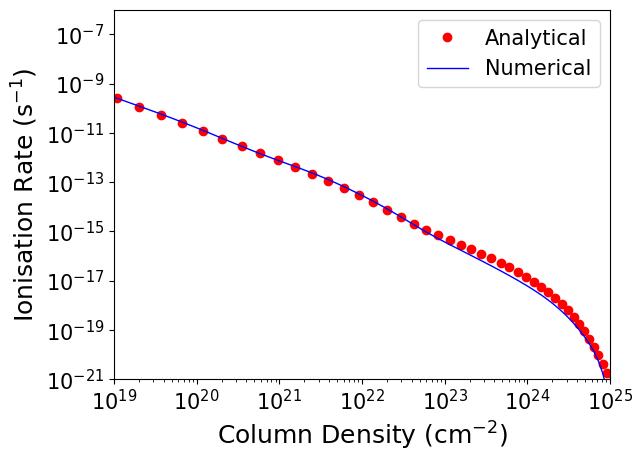

In [227]:
ir = 33
zetaGCR=[1e-19]*len(Ncol[ir])
#zetaGCR=DiscModel.zetaCR[ir]
plt.plot(Ncol[ir], ZetaEtot[ir],'o',label='Analytical', color='red',linewidth=2)
plt.plot(Ncol[ir], DiscModel.zetaSTCR[ir],label='Numerical', color='blue',linewidth=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Column Density (cm$^{-2}$)',fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Ionisation Rate (s$^{-1}$)',fontsize=18)

#plt.title('Ionisation Rate at 1 AU')
plt.ylim(1E-21, 1E-6)
plt.xlim(1E19, 1E25)
plt.legend(fontsize=15)
plt.show()

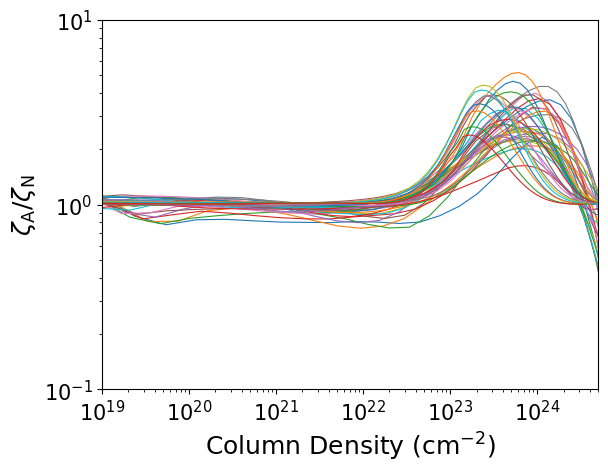

In [225]:

radialrange = range(11, 55)
for ir in radialrange:
    
    plt.plot(Ncol[ir], (ZetaEtot[ir]+DiscModel.zetaCR[ir]+DiscModel.zetaX[ir])/(DiscModel.zetaSTCR[ir]+DiscModel.zetaCR[ir]+DiscModel.zetaX[ir]),linewidth=0.8)
    #plt.plot(Ncol[ir], DiscModel.zetaSTCR[ir],label='Numerical', color='blue',linewidth=1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Column Density (cm$^{-2}$)',fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('$ \\zeta_{\\rm A} / \\zeta_{\\rm N}$',fontsize=18)

#plt.title('Ionisation Rate at 1 AU')
plt.ylim(0.1, 10)
plt.xlim(1E19, 5E24)
#plt.legend(fontsize=15)
plt.show()

In [210]:
#In both these region the IR is dominate by other sources than EP, so the exact value of the EP ionization rate is not important for the chemistry. Below 1e15 cm^-2, the CSDA overestimates the ionization rate, so we set it to zero to avoid overestimating the ionization rate in this regime. Above 1e25 cm^-2, the ionization rate should be negligible, so we set it to a very low value to avoid numerical issues.
ZetaEPrimMap=np.where(DiscModel.NHver>1e15, ZetaEPrimMap, 0) # We force the ionization rate to be zero below the CSDA validity range, as the CSDA overestimates the ionization rate in this regime. 
ZetaEPrimMap = np.where(DiscModel.NHver > 1e25, 1e-40, ZetaEPrimMap) #The CSDA overestimate IR out of its validity range. Above the CSDA validity range, the ionization rate should be negligible, so we set it to a very low value to avoid numerical issues.

/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/1945380250.py:4: RuntimeWarning: divide by zero encountered in divide
  Map2=DiscModel.zetaX/ZetaEPrimMap
/var/folders/fh/vqsmw87j28x32rq1mbvyd1680000gn/T/ipykernel_15161/1945380250.py:6: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(np.flip(grilleXAUliste/autocm, axis=1), np.flip(grilleZAUliste/grilleXAUliste, axis=1), ZetaEPrimMap, cmap='viridis', norm=LogNorm(vmin=vmin, vmax=vmax))


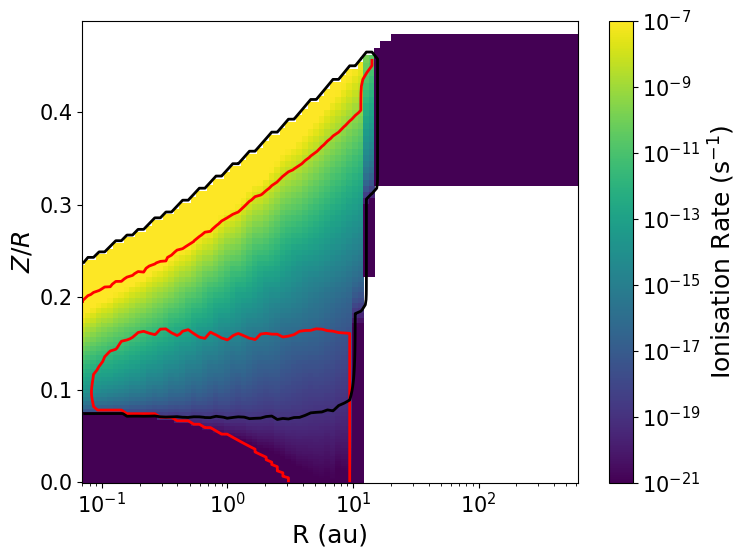

In [211]:

vmin=1E-21
vmax=1E-7
name='Ionisation Rate (s$^{-1}$)'
Map2=DiscModel.zetaX/ZetaEPrimMap
plt.figure(figsize=(8, 6))
plt.pcolor(np.flip(grilleXAUliste/autocm, axis=1), np.flip(grilleZAUliste/grilleXAUliste, axis=1), ZetaEPrimMap, cmap='viridis', norm=LogNorm(vmin=vmin, vmax=vmax))
#plt.pcolor(grilleXAUliste, grilleZAUliste/grilleXAUliste, Aml, cmap='viridis', vmin=vmin, vmax=vmax)

plt.xlabel('R (au)',fontsize=18)
plt.ylabel('$Z/R$',fontsize=18)
#plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste,alpha, cmap='viridis', norm=LogNorm(0.1, 1))
# Write the value of the contour line on the plot

cb=plt.colorbar(label=str(name))
cb.set_label(label=str(name), size=18)


cb.ax.tick_params(labelsize=15)
contour_levels = [ 1E0]
contours = plt.contour(np.flip(grilleXAUliste/autocm, axis=1), np.flip(grilleZAUliste/grilleXAUliste, axis=1), Map2, levels=contour_levels, colors='red', linewidths=2)
#plt.clabel(contours, fontsize=10)

contour_levels = [1E-19]
contours = plt.contour(np.flip(grilleXAUliste/autocm, axis=1), np.flip(grilleZAUliste/grilleXAUliste, axis=1), ZetaEPrimMap, levels=contour_levels, colors='black', linewidths=2)
#plt.clabel(contours, fontsize=10)
#cb.set_label(label='1E-6', size=15)
#plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste,Aml, cmap='viridis')
#cb.set_label(label=str(name), size=15)
#plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste, Rml, [0,1000])
#plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste, Aml, [1E-1,1E30])
#plt.contour(grilleXAUliste, grilleZAUliste/grilleXAUliste, Rml, [3000,1E30])
#plt.ylim(0,0.5)

plt.xscale('log')
#plt.xlim(0.07,50)
#plt.ylim(0.0,0.5)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(0.05,0.25)
#plt.title('Ionization plot')
plt.show()

In [212]:
#ZetaEPrimMap=ZetaEPrimMap[:,::-1]

Acceleration_Region=np.flip(Acceleration_Region, axis=1)

PLOT: plot_cont ...
PLOT: plot_cont ...


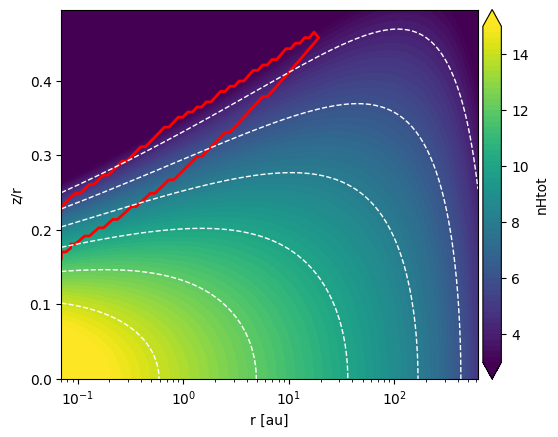

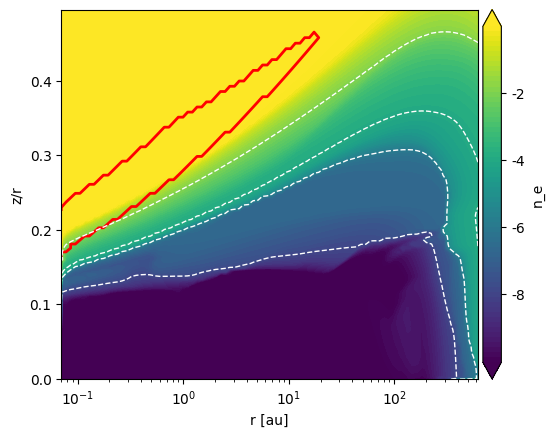

In [213]:
# plot it for checking
from xml.parsers.expat import model
from numpy import mod


pp=pplot.Plot(None)
# gas number density, for many fields it is only necessary to provide the filed name, a nice label for the colorbar and the unit is then selected.
# one can always overwrite this (see next example)
Acceleration_Region_contour=pplot.Contour(Acceleration_Region, [0], colors='red', linewidths=2)

fig=pp.plot_cont(DiscModel,DiscModel.nHtot,label="nHtot",zlim=[1e3,1e15],oconts=[Acceleration_Region_contour],coutour=True,extend="both",cb_format="%.0f")
fig=pp.plot_cont(DiscModel,DiscModel.getAbun('e-'),label="n_e",zlim=[1e-10,1e0],oconts=[Acceleration_Region_contour],coutour=True,extend="both",cb_format="%.0f")


In [214]:
def Write_2D_Ionisation_rate(directory,IonisationRateMapliste,DiscModelName):
    
    # Create a directory to store the text file
    #directory = "PropagatedSpectra"
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Create the text file
    filename = "Ionisation_Rate_Map_"+DiscModelName+".txt"
    filepath = os.path.join(directory, filename)
    # Save IonisationRateMapliste in a text file
    np.savetxt(filepath, IonisationRateMapliste, delimiter=',')

Write_2D_Ionisation_rate("IonisationRateMaps",ZetaEPrimMap,DiscModelName)